In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

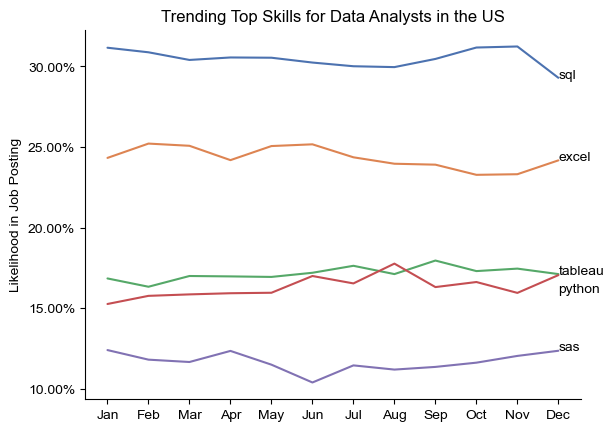

In [ ]:
df_DA = df.query(
    "job_title_short == 'Data Analyst' and" \
    " job_country == 'United States'"
).copy()

df_DA['job_month'] = df_DA['job_posted_date'].dt.month

df_exploded = df_DA.explode('job_skills')

df_pivot = df_exploded.pivot_table(
    index = 'job_month',
    columns = 'job_skills',
    aggfunc= 'size',
    fill_value=0
)

df_pivot.loc['Total'] = df_pivot.sum()
df_pivot = df_pivot[df_pivot.loc['Total'].sort_values(ascending=False).index]
df_pivot = df_pivot.drop('Total')

df_pivot.index = pd.to_datetime(df_pivot.index, format='%m').strftime('%b')

df_plot = df_pivot.iloc[:, :5]
df_percent = df_plot.div(df_plot.sum(axis = 1), axis = 0).copy()

for i, skill in enumerate(df_percent):

    if i == 3:
        plt.text(11, 0.16, skill)
    
    else:
        plt.text(11, df_percent.iloc[-1, i], skill)

sns.set_theme(style="ticks")
sns.lineplot(data = df_percent, dashes = False, legend= False,)

ax = plt.gca()
ax.yaxis.set_major_formatter((plt.FuncFormatter(lambda y, pos: f'{y*100:.2f}%')))

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
sns.despine()
plt.xlabel("")
plt.subplots_adjust()
plt.show()
